<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_2_kellydecastro_matematica_computacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aluna:** 40131556 - Kelly Christine Alvarenga de Castro (christine.kelly@pucpr.edu.br)  
**Mestrado / Turma:** PPGIa (404) 2026/02  
**Disciplina:** Fundamentos de Matemática Computacional (Turma ME)  
**Professor:** Dr. Vinícius Mourão Alves de Souza  

# ATIVIDADE 2 — Vetores, Produto Escalar e Produto de Hadamard

Notebook criado para resolver a **Atividade 2** utilizando os conceitos trabalhados em aula: criação e manipulação de vetores, produto escalar, propriedades comutativa e distributiva, não associatividade, produto de Hadamard e visualização tridimensional com Matplotlib.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuração apenas para melhorar a exibição dos vetores no notebook.
np.set_printoptions(precision=2, suppress=True)

## Exercise 1 — Step 1: criação dos vetores

Devem ser criados três vetores de dimensão 10:

- **A:** valores reais no intervalo $[0,1)$;
- **B:** valores inteiros no intervalo $[50,100)$;
- **C:** valores reais no intervalo $[50,100)$.

Para os vetores reais, o enunciado pede apenas duas casas decimais. Para garantir simultaneamente o intervalo semiaberto e exatamente centésimos válidos, os valores de **A** e **C** são sorteados inicialmente como inteiros e depois divididos por 100. Dessa forma, **A** pode variar de 0.00 a 0.99 e **C** de 50.00 a 99.99.

In [2]:
# Semente fixa para tornar a atividade reprodutível.
np.random.seed(42)

# A: valores reais em [0, 1), com duas casas decimais.
A = np.random.randint(0, 100, size=10) / 100

# B: valores inteiros em [50, 100).
B = np.random.randint(50, 100, size=10)

# C: valores reais em [50, 100), com duas casas decimais.
C = np.random.randint(5000, 10000, size=10) / 100

print("Vetor A =", A)
print("Vetor B =", B)
print("Vetor C =", C)

print("\nDimensões:")
print("A:", A.shape)
print("B:", B.shape)
print("C:", C.shape)

Vetor A = [0.51 0.92 0.14 0.71 0.6  0.2  0.82 0.86 0.74 0.74]
Vetor B = [73 85 89 73 52 71 51 73 93 79]
Vetor C = [74.33 61.84 95.55 83.85 91.17 98.43 79.04 54.74 60.82 75.58]

Dimensões:
A: (10,)
B: (10,)
C: (10,)


## Exercise 1 — Step 2: propriedade comutativa do produto escalar

O produto escalar entre dois vetores de mesma dimensão gera um **escalar**:

$$
A\cdot B=\sum_{i=1}^{n} A_iB_i
$$

A propriedade comutativa afirma que:

$$
A\cdot B=B\cdot A
$$

Em NumPy, o produto escalar será calculado com `np.dot`. Como **A** contém valores reais, a comparação é feita com `np.isclose`, que é apropriado para resultados em ponto flutuante.

In [3]:
AB = np.dot(A, B)
BA = np.dot(B, A)

print("A · B =", AB)
print("B · A =", BA)
print("Propriedade comutativa satisfeita?", np.isclose(AB, BA))

A · B = 457.0
B · A = 457.0
Propriedade comutativa satisfeita? True


## Exercise 1 — Step 2: propriedade distributiva

A propriedade distributiva do produto escalar em relação à soma de vetores é:

$$
A\cdot(B+C)=A\cdot B+A\cdot C
$$

Primeiro calcula-se o lado esquerdo com o vetor soma $B+C$. Depois, calcula-se separadamente $A\cdot B$ e $A\cdot C$ e somam-se os dois escalares.

In [4]:
left_distributive = np.dot(A, B + C)
right_distributive = np.dot(A, B) + np.dot(A, C)

print("A · (B + C) =", left_distributive)
print("A · B + A · C =", right_distributive)
print(
    "Propriedade distributiva satisfeita?",
    np.isclose(left_distributive, right_distributive)
)

A · (B + C) = 911.9247999999999
A · B + A · C = 911.9248
Propriedade distributiva satisfeita? True


## Exercise 1 — Step 2: não associatividade

O material da disciplina mostra que o produto escalar envolvendo três vetores **não é associativo** em geral.

Com vetores unidimensionais do NumPy, `np.dot(A, B)` produz um escalar. Ao aplicar novamente `np.dot` entre esse escalar e **C**, o NumPy efetua uma multiplicação escalar-vetor. O mesmo ocorre no outro agrupamento:

$$
(A\cdot B)\,C
\qquad\text{e}\qquad
A\,(B\cdot C)
$$

Para vetores arbitrários, esses dois vetores resultantes normalmente são diferentes.

In [5]:
left_associative_test = np.dot(np.dot(A, B), C)
right_associative_test = np.dot(A, np.dot(B, C))

print("(A · B) · C =", left_associative_test)
print("A · (B · C) =", right_associative_test)

print(
    "Os resultados são diferentes?",
    not np.allclose(left_associative_test, right_associative_test)
)

(A · B) · C = [33968.81 28260.88 43666.35 38319.45 41664.69 44982.51 36121.28 25016.18
 27794.74 34540.06]
A · (B · C) = [28912.41 52155.72  7936.74 40250.61 34014.6  11338.2  46486.62 48754.26
 41951.34 41951.34]
Os resultados são diferentes? True


## Exercise 1 — Step 3: um caso particular em que os resultados coincidem

É possível construir três vetores para os quais os dois agrupamentos produzam o mesmo vetor.

Considere $C=kA$. Então:

$$
B\cdot C=B\cdot(kA)=k(B\cdot A)=k(A\cdot B)
$$

Logo:

$$
A(B\cdot C)=A\,k(A\cdot B)
$$

e

$$
(A\cdot B)C=(A\cdot B)\,kA
$$

Os dois resultados são iguais. Isso é um **caso particular construído**; não significa que o produto escalar passe a ser uma operação associativa em geral.

In [6]:
A3 = np.array([1.0, 2.0, 3.0])
B3 = np.array([4.0, 5.0, 6.0])

# C3 é proporcional a A3.
k = 2
C3 = k * A3

left_step3 = np.dot(np.dot(A3, B3), C3)
right_step3 = np.dot(A3, np.dot(B3, C3))

print("A =", A3)
print("B =", B3)
print("C =", C3)

print("\n(A · B) · C =", left_step3)
print("A · (B · C) =", right_step3)
print("Resultados coincidem?", np.allclose(left_step3, right_step3))

A = [1. 2. 3.]
B = [4. 5. 6.]
C = [2. 4. 6.]

(A · B) · C = [ 64. 128. 192.]
A · (B · C) = [ 64. 128. 192.]
Resultados coincidem? True


### Conclusão do Exercise 1

Os testes numéricos permitem observar diretamente as propriedades estudadas:

- o produto escalar é **comutativo**;
- o produto escalar é **distributivo** em relação à soma;
- para três vetores arbitrários, os agrupamentos usados no enunciado produzem resultados diferentes, evidenciando a **não associatividade**;
- é possível construir um caso especial em que os resultados coincidem, por exemplo quando **C** é proporcional a **A**.

# Exercise 2 — Produto de Hadamard

O produto de Hadamard é uma multiplicação **elemento a elemento**. Para dois vetores tridimensionais

$$
A=(a_1,a_2,a_3)
\quad\text{e}\quad
B=(b_1,b_2,b_3),
$$

o vetor resultante é:

$$
C=A\circ B=(a_1b_1,\;a_2b_2,\;a_3b_3)
$$

Em NumPy, para arrays de mesma dimensão, essa operação é realizada diretamente com o operador `*`.

In [7]:
A2 = np.array([2, -1, 3])
B2 = np.array([4, 2, -2])

# Produto de Hadamard: multiplicação elemento a elemento.
C2 = A2 * B2

print("A =", A2)
print("B =", B2)
print("C = A ∘ B =", C2)

A = [ 2 -1  3]
B = [ 4  2 -2]
C = A ∘ B = [ 8 -2 -6]


## Representação geométrica em 3D

Como **A**, **B** e **C** possuem três componentes, cada um pode ser representado geometricamente em $\mathbb{R}^3$.

Os três vetores serão desenhados a partir da origem $(0,0,0)$ utilizando `quiver`, função do Matplotlib apropriada para representar vetores com direção, sentido e magnitude.

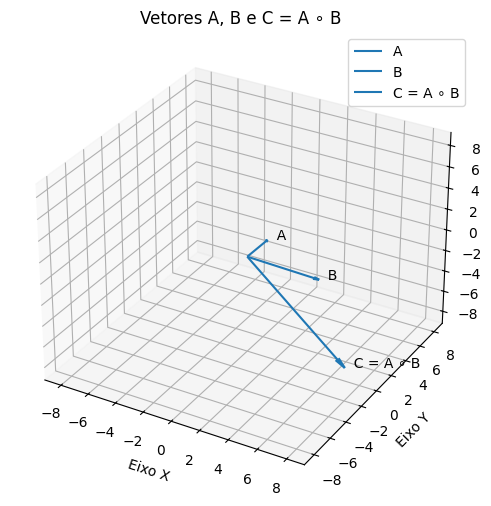

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

origin = np.zeros(3)

for vector, label in [(A2, "A"), (B2, "B"), (C2, "C = A ∘ B")]:
    ax.quiver(
        origin[0], origin[1], origin[2],
        vector[0], vector[1], vector[2],
        arrow_length_ratio=0.08,
        label=label
    )
    ax.text(vector[0], vector[1], vector[2], f"  {label}")

# Usa o mesmo limite nos três eixos para facilitar a comparação visual.
max_abs = np.max(np.abs(np.vstack([A2, B2, C2])))
limit = max_abs * 1.15

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

ax.set_xlabel("Eixo X")
ax.set_ylabel("Eixo Y")
ax.set_zlabel("Eixo Z")
ax.set_title("Vetores A, B e C = A ∘ B")
ax.legend()

plt.show()

### Interpretação do Exercise 2

O vetor **C** não representa um produto escalar. No produto escalar, o resultado entre dois vetores de mesma dimensão é um único número. No produto de Hadamard, cada componente de **A** é multiplicada pela componente correspondente de **B**, e o resultado continua sendo um vetor de mesma dimensão.

Assim, para os valores escolhidos no notebook:

$$
C=(2\cdot4,\;-1\cdot2,\;3\cdot(-2))
$$

A visualização tridimensional permite comparar diretamente direção, sentido e magnitude dos três vetores.

## Referências utilizadas

- SOUZA, Vinícius M. A. **Fundamentals of Computational Mathematics — Week 02**. PUCPR, 2026.
- SON, Hyun-Seok. **Linear Algebra Coding with Python: Python's Application for Linear Algebra**. 2020.
- BROWNLEE, Jason. **Basics of Linear Algebra for Machine Learning: Discover the Mathematical Language of Data in Python**. Machine Learning Mastery, 2018.